# 🎓 Final AI & ML Project: Student Performance Predictor
**Internship:** AI & ML Intern @ Codomax Digital Solutions
**Intern:** Saqlain Munawar
**Module 6 — Day 21–24:** Final AI & ML Project

## 📌 Project Goal
Predict whether a student will **pass or fail** their final exam based on
study habits and lifestyle factors — using a complete, real end-to-end
Machine Learning workflow: data exploration, cleaning, feature analysis,
model training, comparison, and evaluation.

This project brings together everything learned across the internship:
Pandas & NumPy (Module 3), Matplotlib visualization (Module 3),
Scikit-learn model training (Module 4), and applying AI/ML thinking to a
real-world style problem (Module 6).


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

plt.rcParams['figure.figsize'] = (8, 5)


## 2. Create the Dataset

A synthetic **student performance dataset** (500 students) is generated with
realistic relationships: more study hours, higher attendance, a strong
previous score, and enough sleep all push the final score up, while having
a part-time job pulls it down. Random noise is added so the relationships
aren't perfectly clean — just like real data.

Generating the dataset in-notebook means this runs in Google Colab with
zero file uploads.

In [2]:
np.random.seed(42)
n = 500

study_hours = np.clip(np.random.normal(4, 2, n), 0, 10)
attendance = np.clip(np.random.normal(80, 12, n), 40, 100)
previous_score = np.clip(np.random.normal(65, 15, n), 20, 100)
sleep_hours = np.clip(np.random.normal(6.5, 1.3, n), 3, 10)
extracurricular = np.random.choice([0, 1], n, p=[0.55, 0.45])
part_time_job = np.random.choice([0, 1], n, p=[0.7, 0.3])

final_score = (
    study_hours * 3.0
    + attendance * 0.30
    + previous_score * 0.25
    + sleep_hours * 1.0
    - part_time_job * 6
    + extracurricular * 1.5
    - 10
    + np.random.normal(0, 9, n)
)
final_score = np.clip(final_score, 0, 100)
passed = (final_score >= 50).astype(int)

df = pd.DataFrame({
    'study_hours_per_day': np.round(study_hours, 1),
    'attendance_percent': np.round(attendance, 1),
    'previous_exam_score': np.round(previous_score, 1),
    'sleep_hours': np.round(sleep_hours, 1),
    'extracurricular_activities': extracurricular,
    'part_time_job': part_time_job,
    'final_exam_score': np.round(final_score, 1),
    'passed': passed,
})

df.head()


,study_hours_per_day,attendance_percent,previous_exam_score,sleep_hours,extracurricular_activities,part_time_job,final_exam_score,passed
0,5.0,91.1,86.0,7.5,0,0,66.5,1
1,3.7,100.0,78.9,5.8,0,0,40.6,0
2,5.3,63.2,65.9,5.4,0,0,43.5,0
3,7.0,86.8,55.3,6.5,0,0,60.2,1
4,3.5,72.2,75.5,6.3,1,0,50.6,1


## 3. Explore the Dataset

In [3]:
print('Shape:', df.shape)
df.info()


Shape: (500, 8)
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   study_hours_per_day         500 non-null    float64
 1   attendance_percent          500 non-null    float64
 2   previous_exam_score         500 non-null    float64
 3   sleep_hours                 500 non-null    float64
 4   extracurricular_activities  500 non-null    int64  
 5   part_time_job               500 non-null    int64  
 6   final_exam_score            500 non-null    float64
 7   passed                      500 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 31.4 KB


In [4]:
df.describe()


,study_hours_per_day,attendance_percent,previous_exam_score,sleep_hours,extracurricular_activities,part_time_job,final_exam_score,passed
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,4.019600,80.141000,66.594600,6.542800,0.438000,0.288000,47.883200,0.446000
std,1.923647,11.241411,15.077428,1.267304,0.496638,0.453285,12.582284,0.497573
min,0.000000,47.600000,21.600000,3.000000,0.000000,0.000000,8.200000,0.000000
25%,2.600000,72.875000,55.975000,5.700000,0.000000,0.000000,39.675000,0.000000
50%,4.000000,80.300000,66.800000,6.500000,0.000000,0.000000,48.700000,0.000000
75%,5.300000,87.825000,76.325000,7.400000,1.000000,1.000000,56.125000,1.000000
max,10.000000,100.000000,100.000000,10.000000,1.000000,1.000000,84.400000,1.000000


In [5]:
print('Pass rate:', df['passed'].mean())
df['passed'].value_counts()


Pass rate: 0.446


passed
0    277
1    223
Name: count, dtype: int64

### 3.1 Data Cleaning Check

In [6]:
print('Missing values:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())
# Dataset is already clean — generated without gaps or duplicates


Missing values:
study_hours_per_day           0
attendance_percent            0
previous_exam_score           0
sleep_hours                   0
extracurricular_activities    0
part_time_job                 0
final_exam_score              0
passed                        0
dtype: int64

Duplicate rows: 0


### 3.2 Visualize Relationships

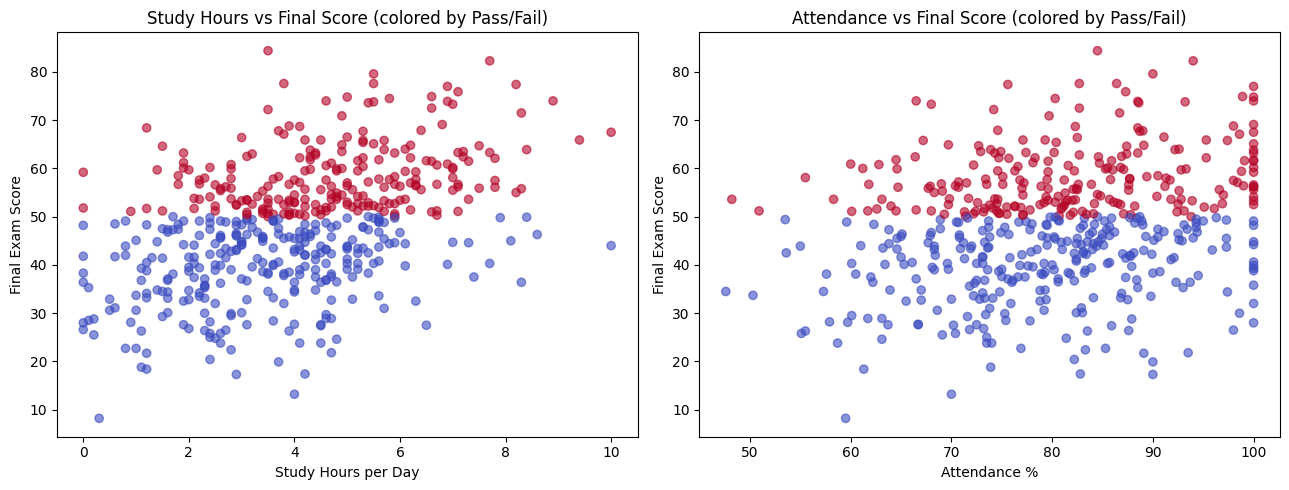

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['study_hours_per_day'], df['final_exam_score'],
                c=df['passed'], cmap='coolwarm', alpha=0.6)
axes[0].set_xlabel('Study Hours per Day')
axes[0].set_ylabel('Final Exam Score')
axes[0].set_title('Study Hours vs Final Score (colored by Pass/Fail)')

axes[1].scatter(df['attendance_percent'], df['final_exam_score'],
                c=df['passed'], cmap='coolwarm', alpha=0.6)
axes[1].set_xlabel('Attendance %')
axes[1].set_ylabel('Final Exam Score')
axes[1].set_title('Attendance vs Final Score (colored by Pass/Fail)')

plt.tight_layout()
plt.show()


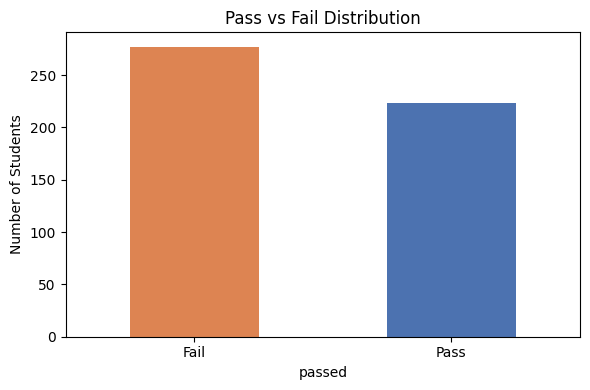

In [8]:
plt.figure(figsize=(6, 4))
df['passed'].value_counts().plot(kind='bar', color=['#DD8452', '#4C72B0'])
plt.xticks([0, 1], ['Fail', 'Pass'], rotation=0)
plt.title('Pass vs Fail Distribution')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()


## 4. Prepare the Data

Split into features (X) and target (y — pass/fail), then into training
and testing sets, and scale the features so every model gets fairly
comparable input.

In [9]:
FEATURES = ['study_hours_per_day', 'attendance_percent', 'previous_exam_score',
            'sleep_hours', 'extracurricular_activities', 'part_time_job']

X = df[FEATURES]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training set:', X_train.shape)
print('Testing set:', X_test.shape)


Training set: (400, 6)
Testing set: (100, 6)


## 5. Train & Compare Multiple Models

Rather than training just one model, three different algorithms are
compared, which is standard practice in a real ML workflow:
- **Logistic Regression** — simple, interpretable baseline
- **Decision Tree** — captures non-linear patterns
- **Random Forest** — an ensemble of trees, usually more robust

In [10]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results[name] = {'model': model, 'accuracy': acc, 'f1': f1}
    print(f'{name}: accuracy={acc:.3f}, f1={f1:.3f}')


Logistic Regression: accuracy=0.710, f1=0.674
Decision Tree: accuracy=0.630, f1=0.602


Random Forest: accuracy=0.720, f1=0.650


### 5.1 Compare Models Visually

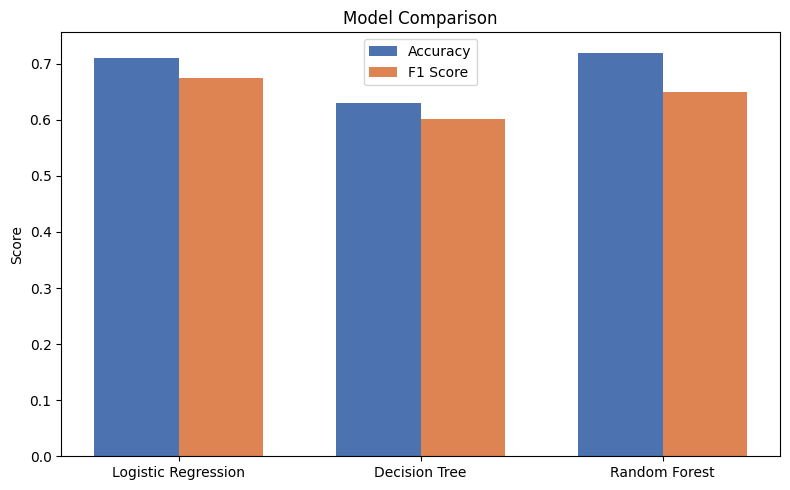

In [11]:
names = list(results.keys())
accuracies = [results[n]['accuracy'] for n in names]
f1_scores = [results[n]['f1'] for n in names]

x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, accuracies, width, label='Accuracy', color='#4C72B0')
plt.bar(x + width/2, f1_scores, width, label='F1 Score', color='#DD8452')
plt.xticks(x, names)
plt.ylabel('Score')
plt.title('Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()


## 6. Evaluate the Best Model

In [12]:
best_name = max(results, key=lambda k: results[k]['f1'])
best_model = results[best_name]['model']
print(f'Best model: {best_name}')

y_pred = best_model.predict(X_test_scaled)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))


Best model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

        Fail       0.73      0.75      0.74        55
        Pass       0.68      0.67      0.67        45

    accuracy                           0.71       100
   macro avg       0.71      0.71      0.71       100
weighted avg       0.71      0.71      0.71       100



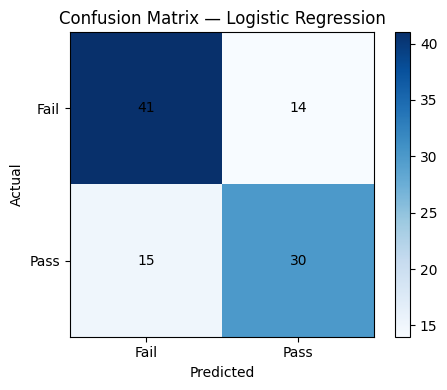

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.colorbar()
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.yticks([0, 1], ['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
plt.show()


## 7. Make a Prediction on a New Student

In [14]:
new_student = pd.DataFrame([{
    'study_hours_per_day': 5.5,
    'attendance_percent': 88,
    'previous_exam_score': 70,
    'sleep_hours': 7,
    'extracurricular_activities': 1,
    'part_time_job': 0,
}])

new_student_scaled = scaler.transform(new_student[FEATURES])
prediction = best_model.predict(new_student_scaled)[0]
probability = best_model.predict_proba(new_student_scaled)[0][1]

print('New student profile:')
print(new_student)
print(f'\nPrediction: {"PASS" if prediction == 1 else "FAIL"}')
print(f'Probability of passing: {probability*100:.1f}%')


New student profile:
   study_hours_per_day  attendance_percent  previous_exam_score  sleep_hours  \
0                  5.5                  88                   70            7   

   extracurricular_activities  part_time_job  
0                           1              0  

Prediction: PASS
Probability of passing: 81.6%


## 8. Key Takeaways

- Built a **complete ML workflow**: data creation → EDA → cleaning →
  feature preparation → training → model comparison → evaluation → prediction
- Compared **three different algorithms** instead of relying on just one,
  and picked the best based on F1 score (balances precision & recall)
- Visualized relationships in the data and the model's performance using
  Matplotlib (scatter plots, bar charts, confusion matrix)
- Used the trained model to predict a **brand-new student's** pass/fail
  outcome with a probability score

This project ties together every skill built during the internship —
Python fundamentals, Pandas/NumPy data handling, Matplotlib visualization,
and Scikit-learn model training — applied to a complete, realistic
end-to-end ML problem. The same trained model also powers a live,
interactive Streamlit web app (see the GitHub repo).
